In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json, os, joblib, datetime
from sklearn.metrics import r2_score, root_mean_squared_error

OPTIONS = json.loads(open('info.json', 'rb').read())
TARGETS = OPTIONS['target_var']
MODEL   = OPTIONS['model']
OPTIONS

{'target_var': ['pitch', 'roll'],
 'seevar': 'wx',
 'n_states': 30,
 'k_cv': 5,
 'model': 'linear_regression',
 'n_iter': 15000,
 'dt': 0.1}

# COMPARAÇÃO DE MODELOS

In [2]:
df    = []
saved = [name for name in os.listdir('Backup') if name.startswith('model_')]    # FORA OS CSV TEMPORÁRIOS

for path in saved:
    index = int(path.split('_')[-1])
    
    with open(f'Backup/{path}/info.json', 'r', encoding='utf-8') as file:
        data = json.loads(file.read())

    if data.get('targets') != TARGETS:    # BACKUP DE OUTRAS SAÍDAS: AS MÉTRICAS NÃO SÃO COMPARÁVEIS
        continue
    
    name = data['model']
    data = data['info']
    data['name'] = name
    data['id'] = index
    df.append(data)


df = pd.DataFrame(df)
df

,r2,r2_adj,rmse,mae,r2_pitch,r2_roll,name,id
0,0.719198,0.417674,0.268598,0.213355,0.439007,0.99939,linear_regression,3
1,0.719198,0.417674,0.268598,0.213355,0.439007,0.99939,linear_regression,4


In [3]:
df = df.sort_values(by='r2_adj', ascending=False)
df

,r2,r2_adj,rmse,mae,r2_pitch,r2_roll,name,id
0,0.719198,0.417674,0.268598,0.213355,0.439007,0.99939,linear_regression,3
1,0.719198,0.417674,0.268598,0.213355,0.439007,0.99939,linear_regression,4


Text(0, 0.5, 'R2 Adjusted')

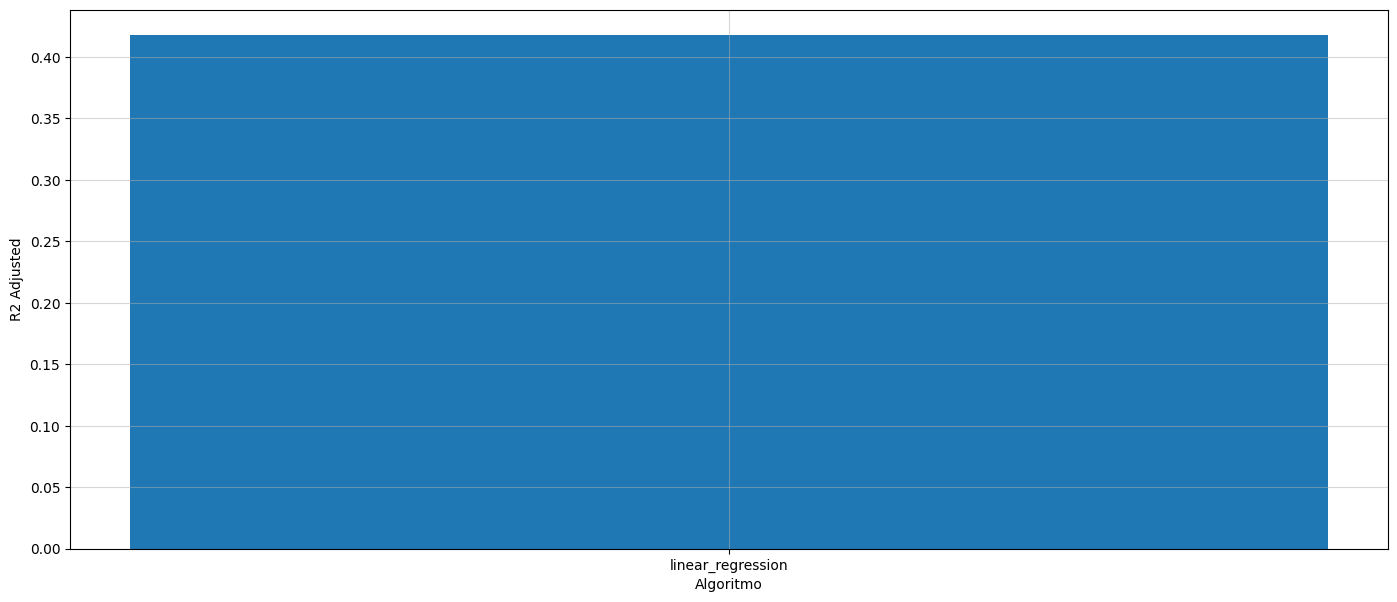

In [4]:
plt.figure(figsize=(17, 7))
plt.bar(df.name, df.r2_adj)
plt.grid(alpha=0.5)
plt.xlabel('Algoritmo'); plt.ylabel('R2 Adjusted')

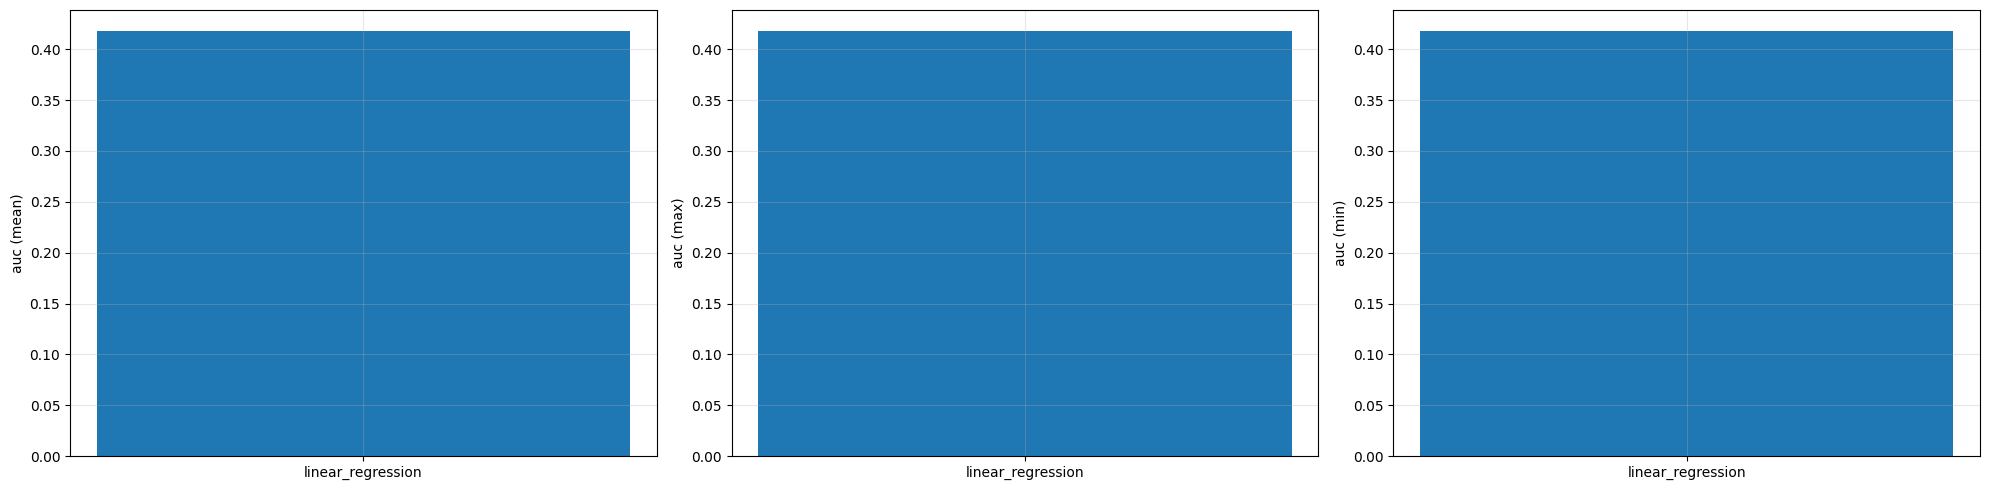

In [5]:
def plotSummary(metric):
    data = {}

    for name in df.name.unique():
        auc = df.loc[df.name == name].r2_adj.agg(metric)
        data[name] = auc
    
    plt.bar(data.keys(), data.values())
    plt.ylabel(f'auc ({metric})')
    plt.grid(alpha=0.3)
    plt.tight_layout()


plt.figure(figsize=(20, 5))
plt.subplot(1, 3, 1)
plotSummary('mean')

plt.subplot(1, 3, 2)
plotSummary('max')

plt.subplot(1, 3, 3)
plotSummary('min')

# SELECIONANDO MODELO

In [6]:
target = df.loc[df.name == MODEL].sort_values(by='r2_adj', ascending=False)
target

,r2,r2_adj,rmse,mae,r2_pitch,r2_roll,name,id
0,0.719198,0.417674,0.268598,0.213355,0.439007,0.99939,linear_regression,3
1,0.719198,0.417674,0.268598,0.213355,0.439007,0.99939,linear_regression,4


In [7]:
def loadModel(id):
    with open(f'Backup/model_{id}/info.json', 'r', encoding='utf-8') as file:
        data = json.loads(file.read())

    data['model'] = joblib.load(f'Backup/model_{id}/model.pkl')
    return data


id   = target.iloc[0].id
data = loadModel(id)
data

{'model': Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())]),
 'params': {'memory': 'None',
  'steps': "[('scaler', StandardScaler()), ('model', LinearRegression())]",
  'transform_input': 'None',
  'verbose': 'False',
  'scaler': 'StandardScaler()',
  'model': 'LinearRegression()',
  'scaler__copy': 'True',
  'scaler__with_mean': 'True',
  'scaler__with_std': 'True',
  'model__copy_X': 'True',
  'model__fit_intercept': 'True',
  'model__n_jobs': 'None',
  'model__positive': 'False',
  'model__tol': '1e-06'},
 'K_CV': 5,
 'info': {'r2': 0.7191982775,
  'r2_adj': 0.4176736492,
  'rmse': 0.2685980447,
  'mae': 0.2133548115,
  'r2_pitch': 0.4390065306,
  'r2_roll': 0.9993900243},
 'targets': ['pitch', 'roll'],
 'variables': ['wx',
  'wx(n-1)',
  'wx(n-2)',
  'wx(n-3)',
  'wx(n-4)',
  'wx(n-5)',
  'wx(n-6)',
  'wx(n-7)',
  'wx(n-8)',
  'wx(n-9)',
  'wx(n-10)',
  'wx(n-11)',
  'wx(n-12)',
  'wx(n-13)',
  'wx(n-14)',
  'wx(n-15)',
  'wx(n-16)',
  'wx(n-17)',
  'wx(

In [8]:
variables = data['variables']
model = data['model']
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


# CARREGANDO DADOS

In [9]:
df = pd.read_csv('Backup/model.csv')
df.head(3)

,time,wx,wx(n-1),wx(n-2),wx(n-3),wx(n-4),wx(n-5),wx(n-6),wx(n-7),wx(n-8),...,az(n-22),az(n-23),az(n-24),az(n-25),az(n-26),az(n-27),az(n-28),az(n-29),pitch,roll
0,2.9,-61.81249,-55.61883,-46.32656,-35.58222,-22.03634,-7.44627,7.68209,21.68968,35.98178,...,0.216609,0.057094,-0.152699,-0.208931,-0.455019,-2.312996,-0.532550,-0.614769,0.455501,-83.995613
1,3.0,-64.39786,-61.81249,-55.61883,-46.32656,-35.58222,-22.03634,-7.44627,7.68209,21.68968,...,0.149904,0.216609,0.057094,-0.152699,-0.208931,-0.455019,-2.312996,-0.532550,0.479107,-90.355444
2,3.1,-63.49374,-64.39786,-61.81249,-55.61883,-46.32656,-35.58222,-22.03634,-7.44627,7.68209,...,0.129869,0.149904,0.216609,0.057094,-0.152699,-0.208931,-0.455019,-2.312996,0.513829,-96.772572


# APLICANDO O MODELO
As métricas de `info.json` vêm da validação cruzada temporal; o gráfico abaixo é só a conferência visual
sobre a série inteira, com o modelo já treinado nela.

pitch: R2=0.6917 RMSE=0.2781 graus
roll: R2=0.9997 RMSE=0.1317 graus


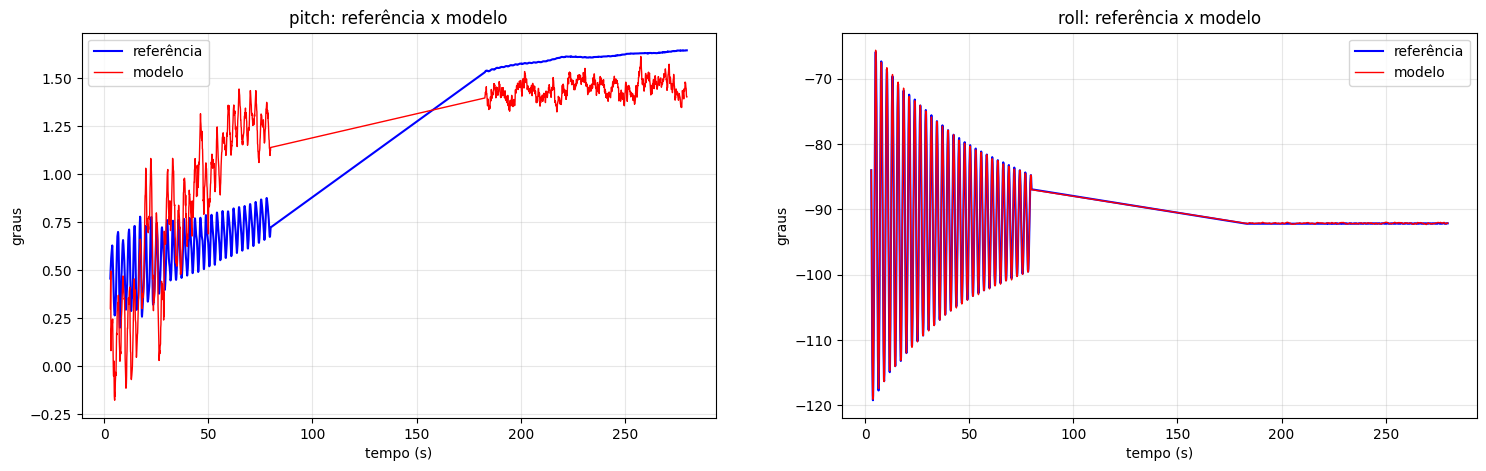

In [10]:
result = pd.DataFrame(model.predict(df[variables]), columns=TARGETS)

for target in TARGETS:
    print(f'{target}: R2={r2_score(df[target], result[target]):.4f} RMSE={root_mean_squared_error(df[target], result[target]):.4f} graus')


plt.figure(figsize=(9*len(TARGETS), 5))

for i, target in enumerate(TARGETS):
    plt.subplot(1, len(TARGETS), i+1)
    plt.plot(df.time, df[target], label='referência', color='blue')
    plt.plot(df.time, result[target], label='modelo', color='red', linewidth=1)

    plt.title(f'{target}: referência x modelo'); plt.xlabel('tempo (s)'); plt.ylabel('graus')
    plt.grid(alpha=0.3); plt.legend()

plt.show()

# ERRO DE INFERÊNCIA

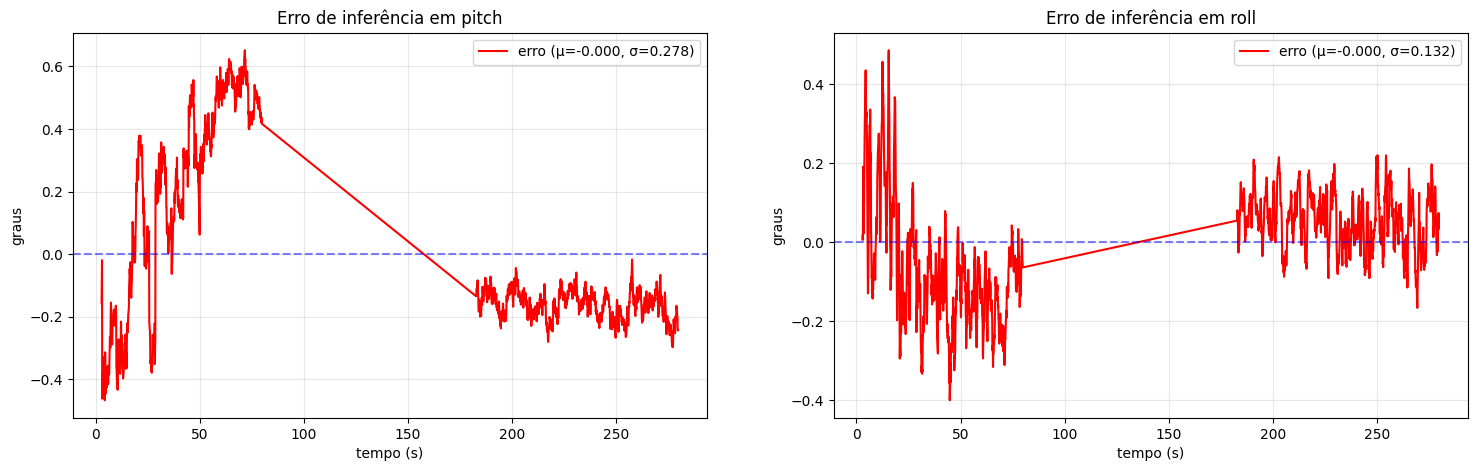

In [11]:
plt.figure(figsize=(9*len(TARGETS), 5))

for i, target in enumerate(TARGETS):
    error = result[target] - df[target]

    plt.subplot(1, len(TARGETS), i+1)
    plt.plot(df.time, error, label=f'erro (µ={error.mean():.3f}, σ={error.std():.3f})', color='red')
    plt.axhline(0, color='blue', linestyle='--', alpha=0.5)

    plt.title(f'Erro de inferência em {target}'); plt.xlabel('tempo (s)'); plt.ylabel('graus')
    plt.grid(alpha=0.3); plt.legend()

plt.show()

# SALVANDO O MODELO
- Os ângulos previstos ao lado dos da referência (`_ref`)

In [12]:
TEST    = json.loads(open('../../info.json', 'r').read()).get('test', 1)
RESULTS = f'../../Dataset/test{TEST}/results'

attitude = pd.DataFrame({'time': df.time})

for target in TARGETS:
    attitude[target]          = result[target]
    attitude[f'{target}_ref'] = df[target]

record = {
    'strategy': 'machine_learning',
    'backup':   f'Model/MachineLearning/Backup/model_{id}',
    'targets':  TARGETS,
    'metrics':  data['info']
}

os.makedirs(RESULTS, exist_ok=True)
attitude.to_csv(f'{RESULTS}/model.csv', index=None)
pd.Series(record).to_json(f'{RESULTS}/model.json', indent=4)
print(f'{RESULTS}/model.csv')
attitude

../../Dataset/test1/results/model.csv


,time,pitch,pitch_ref,roll,roll_ref
0,2.9,0.298561,0.455501,-83.978306,-83.995613
1,3.0,0.396945,0.479107,-90.349291,-90.355444
2,3.1,0.494832,0.513829,-96.757687,-96.772572
3,3.2,0.079837,0.541159,-102.711657,-102.903220
4,3.3,0.121240,0.561269,-108.242266,-108.403615
...,...,...,...,...,...
1737,279.4,1.447216,1.644962,-92.095093,-92.131613
1738,279.5,1.446650,1.645535,-92.089942,-92.131613
1739,279.6,1.413855,1.644962,-92.057246,-92.131613
1740,279.7,1.401683,1.645535,-92.082264,-92.131613


# EXPORTANDO PARA O FIRMWARE
- Vai a padronização e os coeficientes do modelo escolhido, na ordem em que o firmware entrega os sensores
- `MACHINE_PERIOD` é o passo do treino: no MRU o modelo só anda nessa taxa, senão a janela de 30 estados cobre outro tempo
- O `config.h` do `processing` diz qual modelo o firmware compila; quem exportar por último é quem roda

In [13]:
FIRMWARE = '../../../Hardware/Embedded/Main/objects/processing'
SENSORS  = ['ax', 'ay', 'az', 'wx', 'wy', 'wz']
STAMP    = f'{datetime.date.today():%d/%m/%Y}'

scaler, machine = model.named_steps['scaler'], model.named_steps['model']
inputs  = [var for var in SENSORS if var in variables]
states  = len(variables) // len(inputs)
columns = [variables.index(var if lag == 0 else f'{var}(n-{lag})') for var in inputs for lag in range(states)]

toArray = lambda values: ', '.join(f'{value:.8e}f' for value in values)
coef    = ',\n\t'.join('{' + toArray(row[columns]) + '}' for row in machine.coef_)
sensor  = ', '.join(str(SENSORS.index(var)) for var in inputs)
target  = ', '.join(str(TARGETS.index(name)) if name in TARGETS else '-1' for name in ['pitch', 'roll', 'yaw'])

header = f'''#ifndef MACHINE_CONFIG_H
#define MACHINE_CONFIG_H

// GERADO POR Calibration/Model/MachineLearning/3 - Compare.ipynb EM {STAMP}
#define MACHINE_NAME    "{record["strategy"]} ({MODEL})"
#define MACHINE_INPUTS  {len(inputs)}
#define MACHINE_STATES  {states}
#define MACHINE_OUTPUTS {len(machine.coef_)}
#define MACHINE_PERIOD  {OPTIONS['dt']:.6f}f

static const int MACHINE_SENSOR[{len(inputs)}] = {{{sensor}}};    // de onde cada bloco le em {SENSORS}
static const int MACHINE_TARGET[3] = {{{target}}};    // saida de pitch, roll e yaw (-1 fica com o angulo do sensor)

static const float MACHINE_MEAN[{len(columns)}] = {{{toArray(scaler.mean_[columns])}}};

static const float MACHINE_SCALE[{len(columns)}] = {{{toArray(scaler.scale_[columns])}}};

static const float MACHINE_COEF[{len(machine.coef_)}][{len(columns)}] = {{
\t{coef}
}};

static const float MACHINE_BIAS[{len(machine.coef_)}] = {{{toArray(machine.intercept_)}}};

#endif
'''

select = f'''#ifndef PROCESSING_CONFIG_H
#define PROCESSING_CONFIG_H
#include "models/machine/index.h"

// GERADO POR Calibration/Model/MachineLearning/3 - Compare.ipynb EM {STAMP}
using ProcessingModel = MachineModel;

#endif
'''

os.makedirs(f'{FIRMWARE}/models/machine', exist_ok=True)
open(f'{FIRMWARE}/models/machine/config.h', 'w').write(header)
open(f'{FIRMWARE}/config.h', 'w').write(select)

print(f'{FIRMWARE}/models/machine/config.h', '|', len(header), 'bytes')
print(header[:header.index('static const float MACHINE_MEAN')])

../../../Hardware/Embedded/Main/objects/processing/models/machine/config.h | 13248 bytes
#ifndef MACHINE_CONFIG_H
#define MACHINE_CONFIG_H

// GERADO POR Calibration/Model/MachineLearning/3 - Compare.ipynb EM 22/09/2026
#define MACHINE_NAME    "machine_learning (linear_regression)"
#define MACHINE_INPUTS  6
#define MACHINE_STATES  30
#define MACHINE_OUTPUTS 2
#define MACHINE_PERIOD  0.100000f

static const int MACHINE_SENSOR[6] = {0, 1, 2, 3, 4, 5};    // de onde cada bloco le em ['ax', 'ay', 'az', 'wx', 'wy', 'wz']
static const int MACHINE_TARGET[3] = {0, 1, -1};    // saida de pitch, roll e yaw (-1 fica com o angulo do sensor)


